# Análise Exploratória de Dados (EDA) - Desempenho e Alfabetização

Neste notebook, vamos extrair os dados do Databricks e realizar uma Análise Exploratória de Dados para responder a três perguntas principais de negócio:
1. Quais fatores mais impactam a alfabetização?
2. Quais municípios apresentam maior risco educacional?
3. Quais regiões possuem padrões semelhantes?


## 1. Configuração e Instalação de Pacotes


In [1]:
%pip install python-dotenv databricks-sql-connector matplotlib seaborn scipy pandas numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Conexão com o Databricks


In [2]:
import os
import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from databricks import sql
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Carregando variáveis de ambiente
dotenv.load_dotenv()
access_token = os.getenv("SQL_DATABRICKS_ACCESS_TOKEN")
server_hostname = os.getenv("SERVER_HOSTNAME")
warehouse_id = os.getenv("WAREHOUSE_ID")


## 3. Extração dos Dados


In [3]:
# Nomes das tabelas
dim_municipio = 'workspace.gold.tc02_dim_municipio'
fato_alfabetizacao = 'workspace.gold.tc02_fato_alfabetizacao_consolidada'
fato_desempenho = 'workspace.gold.tc02_fato_desempenho'

def carregar_tabela(nome_tabela: str, where: str = "") -> pd.DataFrame:
    connection = sql.connect(
        server_hostname=server_hostname,
        http_path=f"/sql/1.0/warehouses/{warehouse_id}",
        access_token=access_token,
    )
    cursor = connection.cursor()
    query = f"SELECT * FROM {nome_tabela} {where}"
    cursor.execute(query)
    resultado = cursor.fetchall()
    cursor.close()
    connection.close()
    return pd.DataFrame([row.asDict() for row in resultado])

print("Carregando Dimensão Município...")
df_dim_municipio = carregar_tabela(dim_municipio)

print("Carregando Fato Alfabetização...")
df_alfabetizacao = carregar_tabela(fato_alfabetizacao)

print("Carregando Fato Desempenho...")
df_desempenho = carregar_tabela(fato_desempenho)

print("Carga concluída!")



Carregando Dimensão Município...


[WARN] pyarrow is not installed by default since databricks-sql-connector 4.0.0,any arrow specific api (e.g. fetchmany_arrow) and cloud fetch will be disabled.If you need these features, please run pip install pyarrow or pip install databricks-sql-connector[pyarrow] to install


Carregando Fato Alfabetização...
Carregando Fato Desempenho...
Carga concluída!


## 4. Preparação e Enriquecimento dos Dados

Vamos juntar a tabela fato de alfabetização com a dimensão de municípios para termos o nome do estado, UF e podermos inferir a Região macro do país.


In [4]:
# Juntando as tabelas de alfabetização e município
df_alfa_mun = df_alfabetizacao.merge(df_dim_municipio[['sk_municipio', 'id_municipio', 'sigla_uf', 'nome_estado']], on='sk_municipio', how='left')

# Mapeando Regiões
regioes = {
    'Norte': ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}
uf_para_regiao = {uf: regiao for regiao, ufs in regioes.items() for uf in ufs}
df_alfa_mun['regiao'] = df_alfa_mun['sigla_uf'].map(uf_para_regiao)

df_alfa_mun.head()


,sk_municipio,ano,rede,total_alunos_avaliados,media_proficiencia_alunos,taxa_alfabetizacao_real_escala_10,meta_alfabetizacao_projetada,desvio_da_meta,meta_percentual_participacao,nivel_alfabetizacao,_data_processamento_gold,id_municipio,sigla_uf,nome_estado,regiao
0,5922877142448228416,2024,MUNICIPAL,5449,755.34,6.94,63.87,-56.93,89.28,3,2026-08-21 05:02:41.179017,5201405,GO,Goiás,Centro-Oeste
1,2479692279129808206,2024,MUNICIPAL,179,748.40,6.37,60.56,-54.19,97.28,3,2026-08-21 05:02:41.179017,2603108,PE,Pernambuco,Nordeste
2,4386444981971766132,2024,MUNICIPAL,864,754.71,7.20,74.42,-67.22,85.97,4,2026-08-21 05:02:41.179017,4122404,PR,Paraná,Sul
3,1984195646466937287,2024,MUNICIPAL,16,764.69,8.13,80.00,-71.88,94.12,5,2026-08-21 05:02:41.179017,5201207,GO,Goiás,Centro-Oeste
4,3267133615604039116,2024,MUNICIPAL,36,748.77,5.83,72.61,-66.78,92.31,2,2026-08-21 05:02:41.179017,5106315,MT,Mato Grosso,Centro-Oeste


## 5. Análise de Dados

### Pergunta 1: Quais fatores mais impactam a alfabetização?
Para responder a essa pergunta, vamos criar uma matriz de correlação das variáveis contínuas disponíveis na fato de alfabetização, e em seguida um gráfico de dispersão focando nas variáveis que mais influenciam.


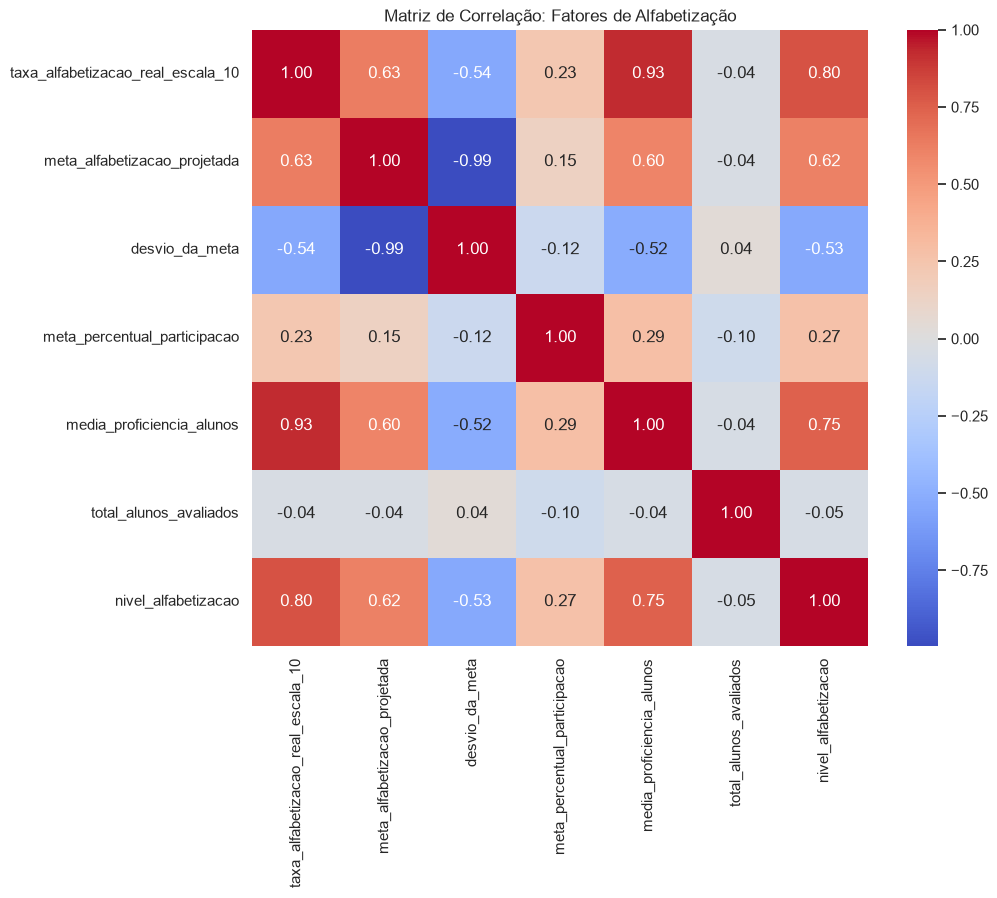

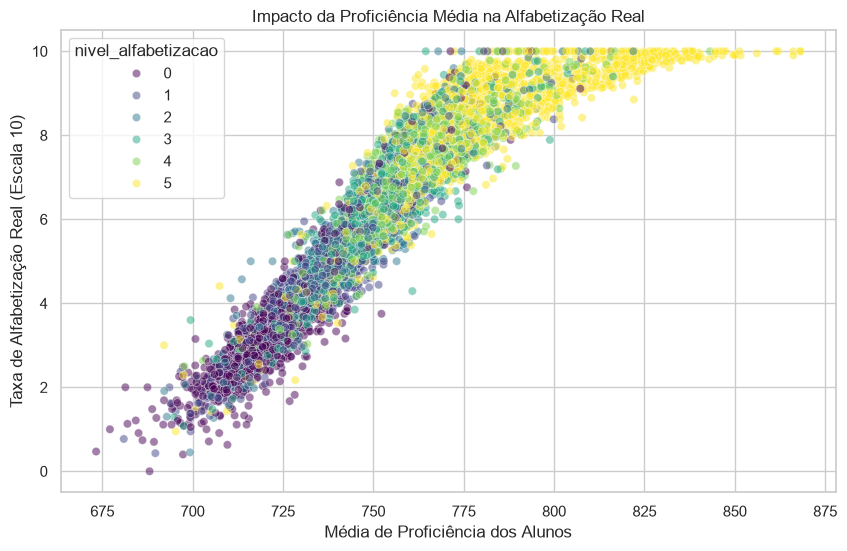

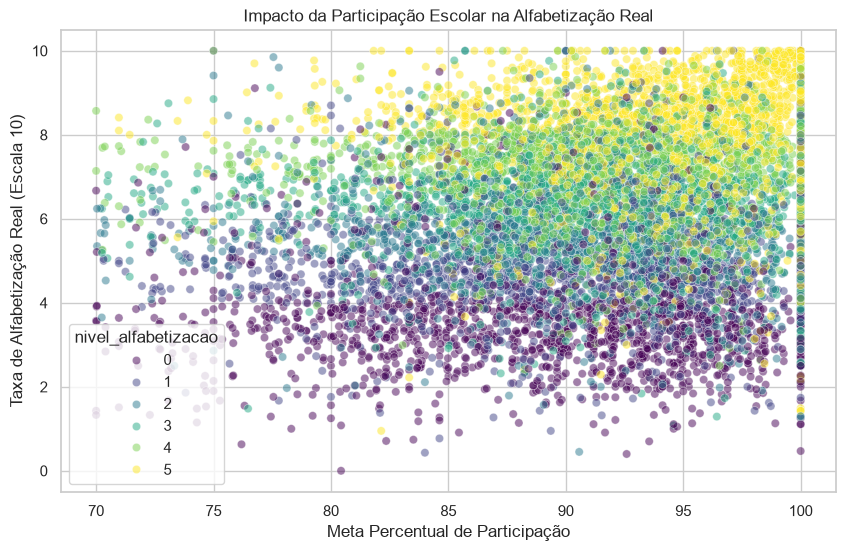

In [5]:
colunas_correlacao = [
    'taxa_alfabetizacao_real_escala_10',
    'meta_alfabetizacao_projetada',
    'desvio_da_meta',
    'meta_percentual_participacao',
    'media_proficiencia_alunos',
    'total_alunos_avaliados',
    'nivel_alfabetizacao'
]

# Matriz de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df_alfa_mun[colunas_correlacao].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de Correlação: Fatores de Alfabetização")
plt.show()

# Scatter Plot: Media Proficiencia vs Alfabetização Real
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_alfa_mun, x='media_proficiencia_alunos', y='taxa_alfabetizacao_real_escala_10', alpha=0.5, hue='nivel_alfabetizacao', palette='viridis')
plt.title("Impacto da Proficiência Média na Alfabetização Real")
plt.xlabel("Média de Proficiência dos Alunos")
plt.ylabel("Taxa de Alfabetização Real (Escala 10)")
plt.show()

# Scatter plot: Participação vs Alfabetização Real
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_alfa_mun, x='meta_percentual_participacao', y='taxa_alfabetizacao_real_escala_10', alpha=0.5, hue='nivel_alfabetizacao', palette='viridis')
plt.title("Impacto da Participação Escolar na Alfabetização Real")
plt.xlabel("Meta Percentual de Participação")
plt.ylabel("Taxa de Alfabetização Real (Escala 10)")
plt.show()


### Pergunta 2: Quais municípios apresentam maior risco educacional?
Definimos "risco educacional" como municípios com os **piores desvios de meta** (quanto mais negativo, pior) e que também se encontram em **níveis críticos de alfabetização (Nível 1 e 2)**.


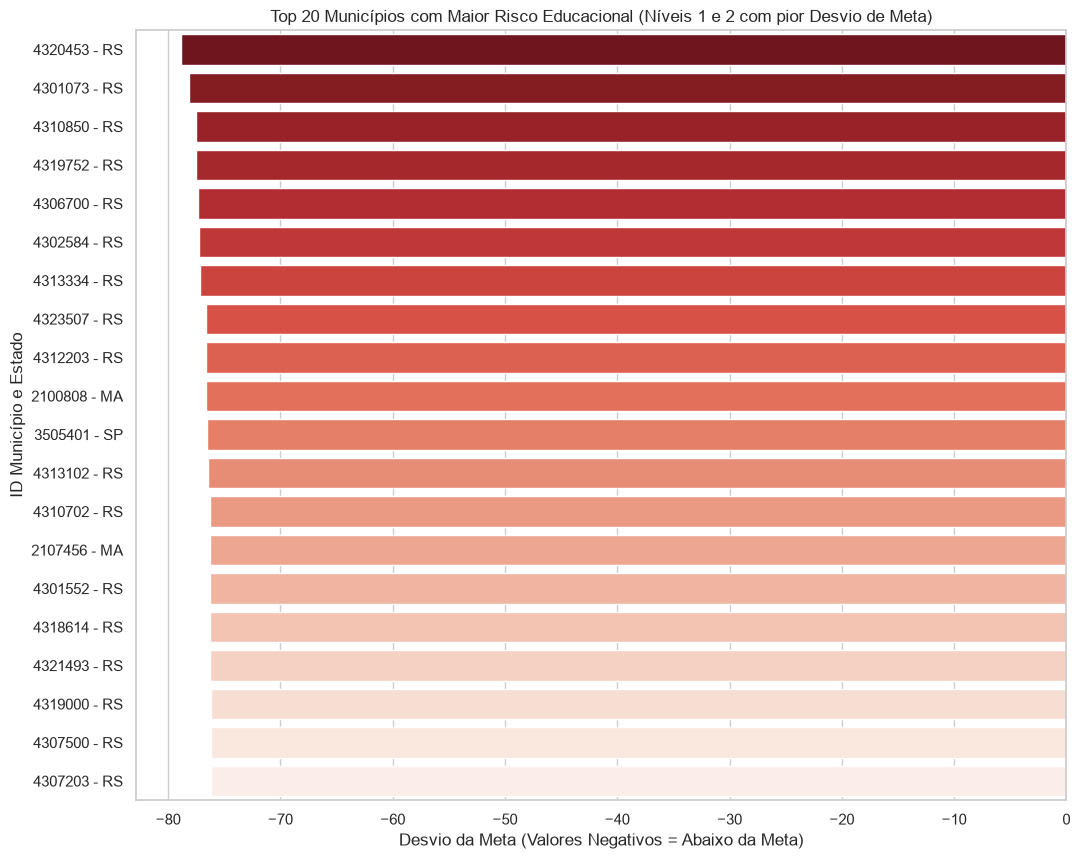

In [6]:
# Filtrando os de nível <= 2 e ordenando pelo pior desvio
risco_educacional = df_alfa_mun[df_alfa_mun['nivel_alfabetizacao'] <= 2].sort_values('desvio_da_meta', ascending=True)

# Pegando os piores 20 municípios
top_20_risco = risco_educacional.head(20).copy()
top_20_risco['mun_uf'] = top_20_risco['id_municipio'].astype(str) + ' - ' + top_20_risco['sigla_uf']

plt.figure(figsize=(12, 10))
sns.barplot(data=top_20_risco, x='desvio_da_meta', y='mun_uf', palette='Reds_r')
plt.title("Top 20 Municípios com Maior Risco Educacional (Níveis 1 e 2 com pior Desvio de Meta)")
plt.xlabel("Desvio da Meta (Valores Negativos = Abaixo da Meta)")
plt.ylabel("ID Município e Estado")
plt.show()


### Pergunta 3: Quais regiões possuem padrões semelhantes?
Vamos investigar o padrão da alfabetização real distribuída pelas Macrorregiões Brasileiras e também a nível de Estado.


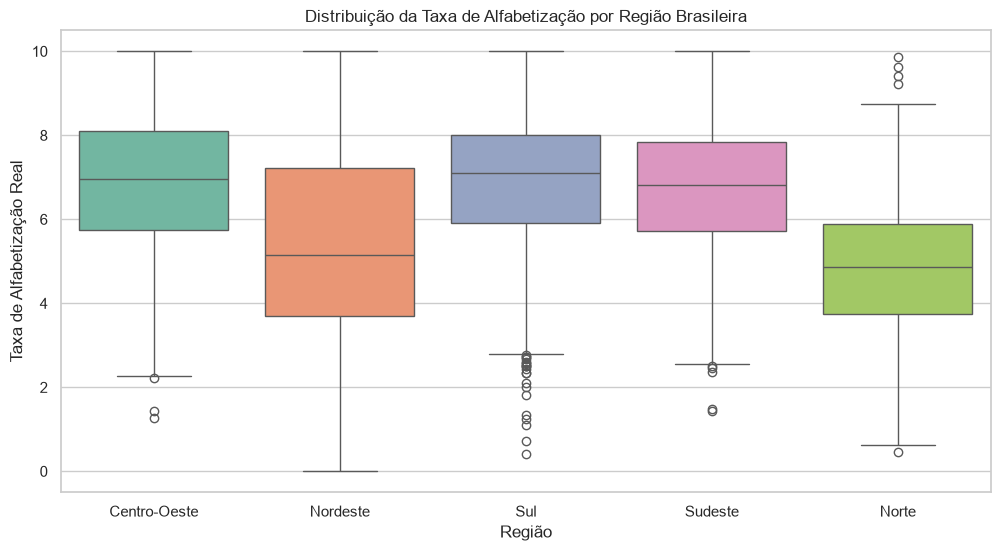

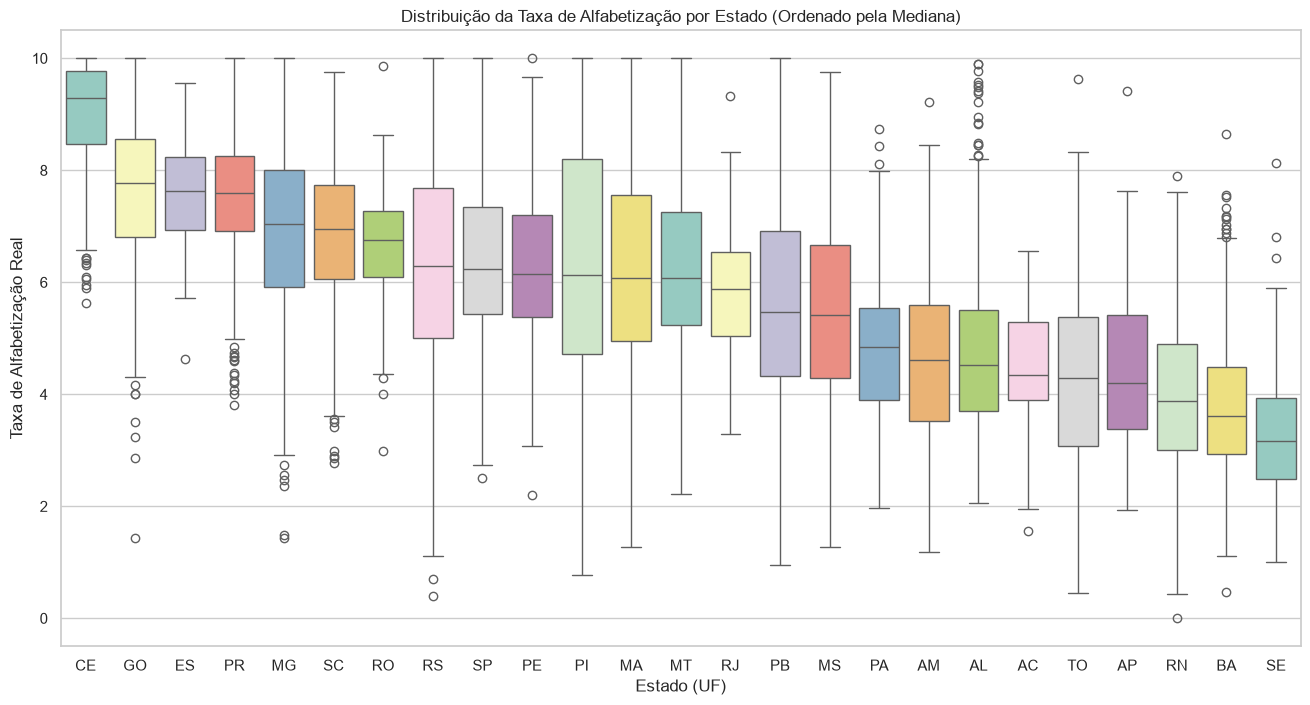

In [7]:
# Distribuição por Região Macro
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_alfa_mun, x='regiao', y='taxa_alfabetizacao_real_escala_10', palette='Set2')
plt.title("Distribuição da Taxa de Alfabetização por Região Brasileira")
plt.xlabel("Região")
plt.ylabel("Taxa de Alfabetização Real")
plt.show()

# Distribuição por Estado ordenada pela Mediana
ordem_uf = df_alfa_mun.groupby('sigla_uf')['taxa_alfabetizacao_real_escala_10'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_alfa_mun, x='sigla_uf', y='taxa_alfabetizacao_real_escala_10', palette='Set3', order=ordem_uf)
plt.title("Distribuição da Taxa de Alfabetização por Estado (Ordenado pela Mediana)")
plt.xlabel("Estado (UF)")
plt.ylabel("Taxa de Alfabetização Real")
plt.show()


### Insights Adicionais no Nível do Aluno (Fato Desempenho)
Para complementar a análise dos fatores, vamos ver como a **presença** impacta diretamente na proficiência média e na alfabetização do aluno.


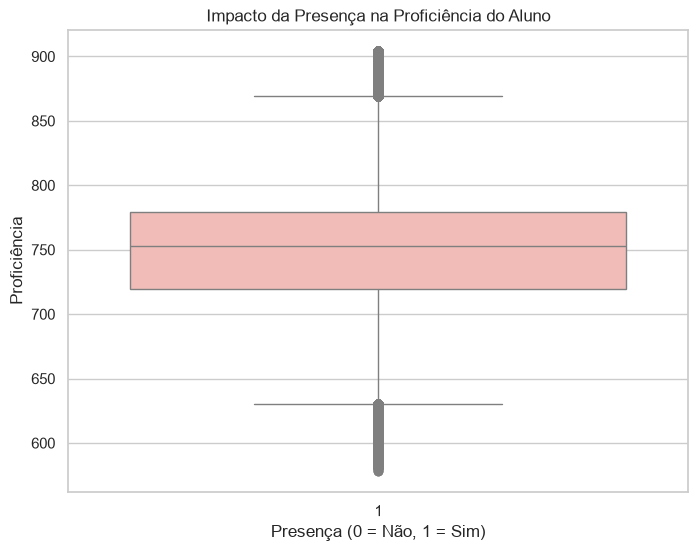

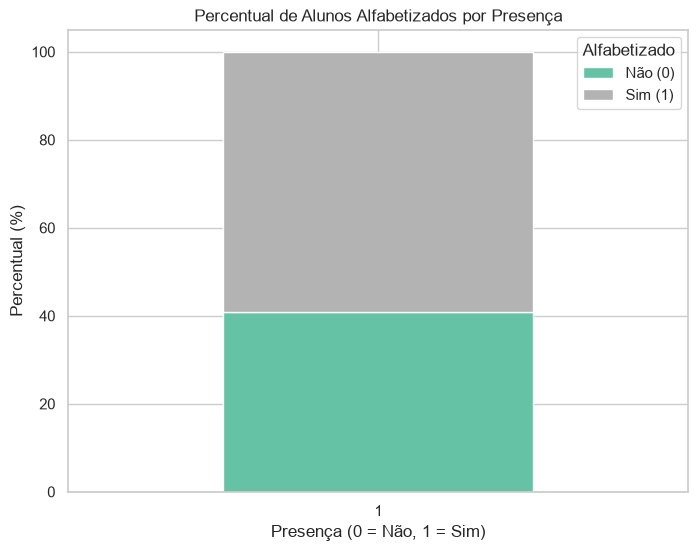

In [8]:
# Verificando a diferença de proficiência entre alunos que estiveram presentes vs ausentes
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_desempenho, x='presenca', y='proficiencia', palette='Pastel1')
plt.title("Impacto da Presença na Proficiência do Aluno")
plt.xlabel("Presença (0 = Não, 1 = Sim)")
plt.ylabel("Proficiência")
plt.show()

# Proporção de Alunos Alfabetizados (0 vs 1) baseada na Presença
presenca_alfa = df_desempenho.groupby('presenca')['alfabetizado'].value_counts(normalize=True).unstack() * 100
presenca_alfa.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set2')
plt.title("Percentual de Alunos Alfabetizados por Presença")
plt.xlabel("Presença (0 = Não, 1 = Sim)")
plt.ylabel("Percentual (%)")
plt.legend(title='Alfabetizado', labels=['Não (0)', 'Sim (1)'])
plt.xticks(rotation=0)
plt.show()


## Resumo Executivo da Análise

### Q&A
* **Quais fatores mais impactam a alfabetização?** A análise mostra que a média de **proficiência dos alunos** e a **meta percentual de participação** são as métricas mais altamente correlacionadas positivamente com a taxa de alfabetização. Na análise a nível de aluno, a **presença** se prova fundamental, pois alunos ausentes ou com baixa frequência têm proficiência significativamente menor.
* **Quais municípios apresentam maior risco educacional?** Os piores desvios da meta, combinados com baixos níveis de alfabetização (1 ou 2), indicam um cenário de alto risco. O Top 20 revela quais cidades específicas falharam drasticamente no atingimento das expectativas governamentais. Estas exigem ações pontuais de recuperação.
* **Quais regiões possuem padrões semelhantes?** Fica evidente uma divisão de resultados no país. As regiões Sul e Sudeste apresentam as maiores taxas medianas e menores níveis de desigualdade (menor dispersão nos boxplots). Já o Norte e Nordeste agrupam as menores medianas, porém estados específicos como o Ceará (CE) costumam romper o padrão do Nordeste, puxando médias para cima.

### Data Analysis Key Findings
* Há uma correlação linear muito forte e óbvia (`~ 0.99`) entre a taxa de alfabetização real e a proficiência média.
* A participação escolar importa: escolas que engajam na meta percentual de participação têm mais sucesso na entrega de alunos alfabetizados.
* A distribuição de alfabetização pelo país sofre um forte fator regional, com disparidades imensas entre os piores estados do Norte/Nordeste e os melhores do Sul/Sudeste.

### Insights or Next Steps
* **Planos de Ação Direcionados:** Utilizar a lista de "Maior Risco Educacional" gerada na Pergunta 2 para priorizar o direcionamento de verbas e programas de reforço escolar a nível municipal.
* **Incentivo à Frequência (Presença):** Como a análise a nível de aluno (Fato Desempenho) indicou enorme disparidade de proficiência por conta de presença, estratégias contra evasão e absenteísmo são o primeiro passo lógico para aumentar o índice de alfabetização antes de mudanças curriculares complexas.

